# Figure plot part3 

## 1 General settings

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [35]:
# color mapping between gene and color
color_list = sns.color_palette("tab20", 14) 
gene_list = ['Lkb1', 'Setd2', 'Rb1', 'Trp53', 'Apc', 'Rbm10', 'Smad4', 'Cdkn2a','PDL1', 'Inert', 'Arid1a', 'Atm', 'Keap1', 'B2M']
# Map the gene list to the color palette
gene_color_map = dict(zip(gene_list, color_list))

In [36]:
bt_summary_path = (
    "data/Adaptive_BT_gRNA_level_summary_df.csv"
)
bt_summary_df = pd.read_csv(bt_summary_path)
bt_summary_df = bt_summary_df[bt_summary_df.Mouse_genotype=='KC']
relative_resistance_effect_path = (
    "data/Adaptive_treatment_gRNA_level_df.csv"
)
relative_resistance_effect_df = pd.read_csv(relative_resistance_effect_path)
relative_resistance_effect_df = relative_resistance_effect_df[relative_resistance_effect_df.Mouse_genotype=='KC']

---

## 2. Direct comparison of tumor size of SIIN-vector vs Control-vector

In [37]:
df1 = bt_summary_df[bt_summary_df.Vector_type == 'Lenti-SIINFEKL']
df2 = bt_summary_df[bt_summary_df.Vector_type == 'Lenti-Control']
temp_shared = ['gRNA', 'Type','Targeted_gene_name','Numbered_gene_name']
df_merge = df1.merge(df2, on = temp_shared, suffixes= ['_HI','_NI'])

### 2.1 QuadraticFit for finding outliers

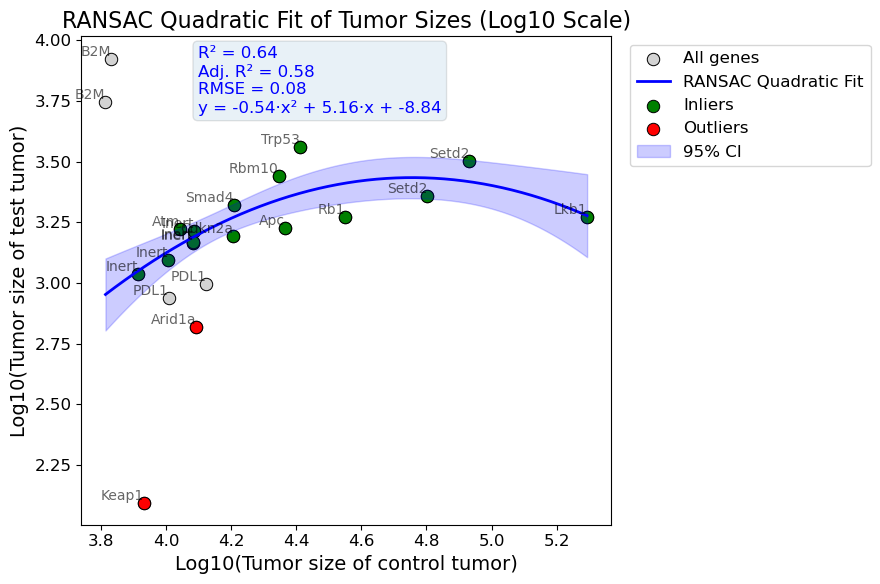

In [38]:
"""
RANSAC Quadratic Fit of Tumor Sizes (Log10-Transformed)

Steps:
1. Import necessary libraries for data manipulation, plotting, and regression.
2. Define focal columns for tumor sizes and create new columns for their log10 transforms.
3. Split the dataset into:
   - temp_df: the full dataset (for background scatter)
   - temp_sub_df: the dataset excluding predefined control genes (for model fitting)
4. Initialize the plot and draw a scatterplot of all genes (background).
5. Prepare quadratic features (x and x²) for the RANSAC regression using temp_sub_df.
6. Fit a RANSACRegressor with a LinearRegression base estimator:
   - Use a residual threshold of log10(2) to flag points beyond a 2-fold change.
   - Require at least 60% of data points to be inliers for model fitting.
7. Generate a smoothed quadratic fit line over the full range of x-values.
8. Identify inliers and outliers from the RANSAC fit and overlay them:
   - Inliers (green) were used to fit the model.
   - Outliers (red) did not satisfy the residual threshold.
9. Compute residuals for inliers and estimate the variance of residuals (σ²).
10. Calculate the covariance matrix for the inlier design matrix and derive the xstandard error
    of the predicted fit at each x, enabling 95% confidence intervals for the quadratic curve.
    - Note: Degrees of freedom in the adjusted R² calculation:
        • n_inliers: number of inlier samples used for fitting
        • p_quadratic_param: number of predictors (excluding the intercept) = 2 (x and x²)
11. Compute R², adjusted R², and RMSE for the inlier-based quadratic model.
12. Annotate the plot with fit statistics, scatter points, confidence band, and gene labels.
13. Finalize axis labels, title, and legend; then display the figure.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Define focal columns and create log10-transformed columns
focal_x = 'LN_mean_NI'
focal_y = 'LN_mean_HI'
ix = f"Log10_{focal_x}"
iy = f"Log10_{focal_y}"

df_merge[ix] = np.log10(df_merge[focal_x])
df_merge[iy] = np.log10(df_merge[focal_y])

# 2. Create full and subset DataFrames
temp_df = df_merge.copy()
excluded_genes = ['B2M', 'PDL1']
temp_sub_df = df_merge[~df_merge.Targeted_gene_name.isin(excluded_genes)].copy()

# 3. Plot setup
x_label = 'Log10(Tumor size of control tumor)'
y_label = 'Log10(Tumor size of test tumor)'
fig1, ax = plt.subplots(figsize=(9, 6))

# 4. Scatter plot of all genes (background)
sns.scatterplot(
    data=temp_df,
    x=ix,
    y=iy,
    ax=ax,
    s=80,
    edgecolor='black',
    color='lightgray',
    label='All genes'
)

# 5. Prepare quadratic features for RANSAC
X = temp_sub_df[[ix]].values
poly = PolynomialFeatures(degree=2, include_bias=False)  # include x and x²
X_poly = poly.fit_transform(X)
y = temp_sub_df[iy].values

# 6. Fit RANSAC quadratic model
#    - base estimator: LinearRegression (fits intercept plus coefficients)
#    - min_samples=0.6: at least 60% of samples must be inliers
#    - residual_threshold=np.log10(2): flags points beyond 2-fold change
ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=0.6,
    residual_threshold=np.log10(2)
)
ransac.fit(X_poly, y)

# 7. Generate a smooth x-range for plotting the fitted curve
x_range = np.linspace(temp_df[ix].min(), temp_df[ix].max(), 200)
X_range_poly = poly.transform(x_range.reshape(-1, 1))
y_fit = ransac.predict(X_range_poly)

# 8. Plot the RANSAC quadratic fit line
ax.plot(x_range, y_fit, color='blue', linewidth=2, label='RANSAC Quadratic Fit')

# 9. Identify inliers and outliers
inlier_mask = ransac.inlier_mask_
outlier_mask = ~inlier_mask

sns.scatterplot(
    data=temp_sub_df[inlier_mask],
    x=ix,
    y=iy,
    ax=ax,
    s=80,
    color='green',
    label='Inliers',
    edgecolor='black'
)
sns.scatterplot(
    data=temp_sub_df[outlier_mask],
    x=ix,
    y=iy,
    ax=ax,
    s=80,
    color='red',
    label='Outliers',
    edgecolor='black'
)

# 10. Compute residuals for inliers
y_pred_inliers = ransac.predict(X_poly[inlier_mask])
residuals = y[inlier_mask] - y_pred_inliers

# 11. Covariance matrix and standard error of fit
X_inliers_design = np.column_stack([
    np.ones(inlier_mask.sum()),   # intercept
    X_poly[inlier_mask]           # x and x^2
])

X_range_design = np.column_stack([
    np.ones(X_range_poly.shape[0]),  # intercept
    X_range_poly                     # x and x^2
])

n_inliers = X_inliers_design.shape[0]
p_params = X_inliers_design.shape[1]   # intercept, x, x^2

var_resid = np.sum(residuals**2) / (n_inliers - p_params)
cov_matrix = np.linalg.pinv(X_inliers_design.T @ X_inliers_design) * var_resid

SE_fit = np.sqrt(np.sum((X_range_design @ cov_matrix) * X_range_design, axis=1))

# 12. 95% confidence intervals
y_upper = y_fit + 1.96 * SE_fit
y_lower = y_fit - 1.96 * SE_fit
ax.fill_between(x_range, y_lower, y_upper, color='blue', alpha=0.2, label='95% CI')

# 13. Compute fit statistics
r2 = r2_score(y[inlier_mask], ransac.predict(X_poly[inlier_mask]))
rmse = np.sqrt(mean_squared_error(y[inlier_mask], ransac.predict(X_poly[inlier_mask])))

n_inliers = inlier_mask.sum()
p_quadratic_param = 2  # predictors: x and x² (excluding intercept)
adj_r2 = 1 - (1 - r2) * (n_inliers - 1) / (n_inliers - p_quadratic_param - 1)

# 14. Annotate equation and fit statistics
coef = ransac.estimator_.coef_
intercept = ransac.estimator_.intercept_
quad_eq = f"y = {coef[1]:.2f}·x² + {coef[0]:.2f}·x + {intercept:.2f}"
stats_text = (
    f"R² = {r2:.2f}\n"
    f"Adj. R² = {adj_r2:.2f}\n"
    f"RMSE = {rmse:.2f}\n"
    f"{quad_eq}"
)
ax.text(
    0.22,
    0.98,
    stats_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    color='blue',
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.1)
)

# 15. Annotate each point with gene name (use a light alpha to reduce clutter)
for _, row in temp_df.iterrows():
    ax.text(
        row[ix],
        row[iy],
        row['Targeted_gene_name'],
        fontsize=10,
        ha='right',
        va='bottom',
        alpha=0.6
    )

# 16. Finalize plot labels, title, and legend
ax.set_xlabel(x_label, fontsize=14)
ax.set_ylabel(y_label, fontsize=14)
ax.set_title('RANSAC Quadratic Fit of Tumor Sizes (Log10 Scale)', fontsize=16)

ax.legend(
    ncol=1,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True
)
plt.tight_layout()
plt.show()

### 2.2 Redo quadratic fit based on the outlier detected above (Fig. 6C)

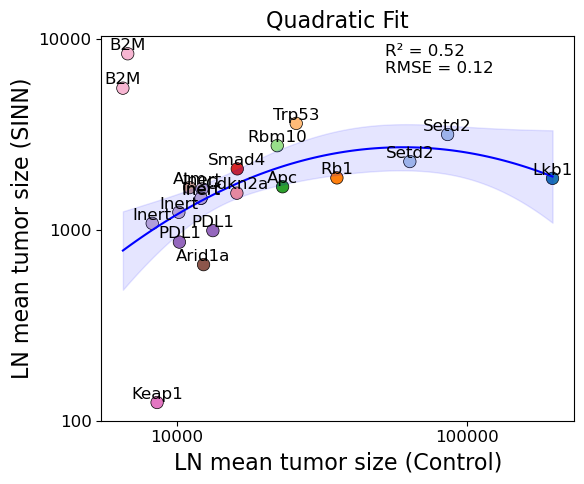

In [39]:

# ────────────────────────────────────────────────────────────────────────────────
# Publication settings and user‐configurable options
# ────────────────────────────────────────────────────────────────────────────────
# Font sizes
font_label_size = 16        # axis labels
font_tick_size = 12        # x/y tick labels
font_text_size = 12         # annotation text (gene names, p‐values)
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['axes.labelsize']  = font_label_size
plt.rcParams['xtick.labelsize'] = font_tick_size
plt.rcParams['ytick.labelsize'] = font_tick_size
plt.rcParams['font.size']       = font_text_size

# Figure size (in inches)
fig_width, fig_height = 6, 5

# ────────────────────────────────────────────────────────────────────────────────

# ────────────────────────────────────────────────────────────────────────────────
# 1. Define focal columns (before log10 transformation)
# ────────────────────────────────────────────────────────────────────────────────
focal_x = 'LN_mean_NI'
focal_y = 'LN_mean_HI'

# ────────────────────────────────────────────────────────────────────────────────
# 2. Log10-transform focal columns
# ────────────────────────────────────────────────────────────────────────────────
ix = f"Log10_{focal_x}"
iy = f"Log10_{focal_y}"
df_merge[ix] = np.log10(df_merge[focal_x])
df_merge[iy] = np.log10(df_merge[focal_y])

# ────────────────────────────────────────────────────────────────────────────────
# 3. Exclude specified genes for fitting
# ────────────────────────────────────────────────────────────────────────────────
excluded_genes = ['B2M', 'PDL1', 'Keap1']
temp_df = df_merge.copy()
temp_sub_df = temp_df.loc[~temp_df['Targeted_gene_name'].isin(excluded_genes)].copy()

# ────────────────────────────────────────────────────────────────────────────────
# 4. Scatterplot setup
# ────────────────────────────────────────────────────────────────────────────────
temp_x_label = 'LN mean tumor size (Control)'
temp_y_label = 'LN mean tumor size (SINN)'
dot_size = 80

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
sns.scatterplot(
    data=temp_df,
    x=ix,
    y=iy,
    hue='Targeted_gene_name',
    palette=gene_color_map,
    edgecolor='black',
    linewidth=0.5,
    s=dot_size,
    ax=ax,
    legend=False
)

# ────────────────────────────────────────────────────────────────────────────────
# 5. Fit a quadratic (deg=2) polynomial to the subset
# ────────────────────────────────────────────────────────────────────────────────
p_quad = np.polyfit(temp_sub_df[ix], temp_sub_df[iy], deg=2)
y_fit_sub = np.polyval(p_quad, temp_sub_df[ix])

x_min, x_max = temp_df[ix].min(), temp_df[ix].max()
x_range = np.linspace(x_min, x_max, 100)
y_fit_range = np.polyval(p_quad, x_range)

# ────────────────────────────────────────────────────────────────────────────────
# 6. Plot quadratic fit and 95% CI band
# ────────────────────────────────────────────────────────────────────────────────
ax.plot(
    x_range,
    y_fit_range,
    color='blue',
    linewidth=1.5
)

# Compute σ_model from subset residuals (ddof=3 for 3 parameters)
residuals_sub = temp_sub_df[iy] - y_fit_sub
var_res = np.var(residuals_sub, ddof=3)

# Build design matrices for CI
X_obs = temp_sub_df[ix].to_numpy()
X_design = np.vstack([X_obs**2, X_obs, np.ones_like(X_obs)]).T
X_rng = np.vstack([x_range**2, x_range, np.ones_like(x_range)]).T
cov_mat = np.linalg.inv(X_design.T @ X_design) * var_res
SE_fit = np.sqrt(np.sum((X_rng @ cov_mat) * X_rng, axis=1))

y_upper = y_fit_range + 1.96 * SE_fit
y_lower = y_fit_range - 1.96 * SE_fit

ax.fill_between(
    x_range,
    y_lower,
    y_upper,
    color='blue',
    alpha=0.1
)

# ────────────────────────────────────────────────────────────────────────────────
# 7. Compute R² and RMSE on the subset, then annotate
# ────────────────────────────────────────────────────────────────────────────────
r2_quad  = r2_score(temp_sub_df[iy], y_fit_sub)
rmse_quad = np.sqrt(mean_squared_error(temp_sub_df[iy], y_fit_sub))

ax.text(
    0.60,
    0.98,
    f'R² = {r2_quad:.2f}\nRMSE = {rmse_quad:.2f}',
    transform=ax.transAxes,
    fontsize=font_text_size,
    verticalalignment='top',
    # bbox=dict(boxstyle='round', alpha=0.1),
    color='black'
)

# ────────────────────────────────────────────────────────────────────────────────
# 8. Annotate gene names
# ────────────────────────────────────────────────────────────────────────────────

for _, row in temp_df.iterrows():
    x, y = row[ix], row[iy]
    gene = row['Targeted_gene_name']
    ax.text(x, y + 0.02, gene, fontsize=font_text_size, color='black', ha='center')

# ────────────────────────────────────────────────────────────────────────────────
# 9. Adjust axis ticks to show original-scale values on log10 axes
# ────────────────────────────────────────────────────────────────────────────────
orig_xticks = [10000, 100000]
ax.set_xticks(np.log10(orig_xticks))
ax.set_xticklabels(orig_xticks)

orig_yticks = [100, 1000, 10000]
ax.set_yticks(np.log10(orig_yticks))
ax.set_yticklabels(orig_yticks)

# ────────────────────────────────────────────────────────────────────────────────
# 10. Finalize labels, title, and optionally save the figure
# ────────────────────────────────────────────────────────────────────────────────
ax.set_xlabel(temp_x_label)
ax.set_ylabel(temp_y_label)
ax.set_title('Quadratic Fit', fontsize=font_label_size)

plt.tight_layout()

plt.show()


### 2.3 Redo linear fit based on the outlier detected above (Fig. S14A)

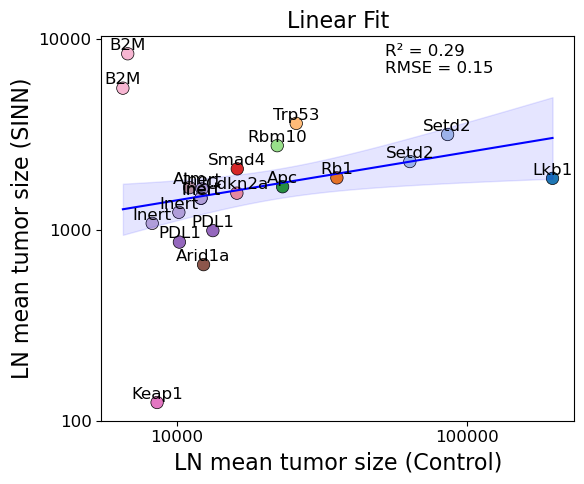

In [40]:

# ────────────────────────────────────────────────────────────────────────────────
# Publication settings and user‐configurable options
# ────────────────────────────────────────────────────────────────────────────────
# Font sizes
font_label_size = 16        # axis labels
font_tick_size = 12         # x/y tick labels
font_text_size = 12         # annotation text (gene names, p‐values)
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['axes.labelsize']  = font_label_size
plt.rcParams['xtick.labelsize'] = font_tick_size
plt.rcParams['ytick.labelsize'] = font_tick_size
plt.rcParams['font.size']       = font_text_size

# Figure size (in inches)
fig_width, fig_height = 6, 5

# ────────────────────────────────────────────────────────────────────────────────
# 1. Define focal columns (before log10 transformation)
# ────────────────────────────────────────────────────────────────────────────────
focal_x = 'LN_mean_NI'
focal_y = 'LN_mean_HI'

# ────────────────────────────────────────────────────────────────────────────────
# 2. Log10-transform focal columns
# ────────────────────────────────────────────────────────────────────────────────
ix = f"Log10_{focal_x}"
iy = f"Log10_{focal_y}"
df_merge[ix] = np.log10(df_merge[focal_x])
df_merge[iy] = np.log10(df_merge[focal_y])

# ────────────────────────────────────────────────────────────────────────────────
# 3. Exclude specified genes for fitting
# ────────────────────────────────────────────────────────────────────────────────
excluded_genes = ['B2M', 'PDL1', 'Keap1']
temp_df = df_merge.copy()
temp_sub_df = temp_df.loc[~temp_df['Targeted_gene_name'].isin(excluded_genes)].copy()

# ────────────────────────────────────────────────────────────────────────────────
# 4. Scatterplot setup
# ────────────────────────────────────────────────────────────────────────────────
temp_x_label = 'LN mean tumor size (Control)'
temp_y_label = 'LN mean tumor size (SINN)'
dot_size = 80

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
sns.scatterplot(
    data=temp_df,
    x=ix,
    y=iy,
    hue='Targeted_gene_name',
    palette=gene_color_map,
    edgecolor='black',
    linewidth=0.5,
    s=dot_size,
    ax=ax,
    legend=False
)

# ────────────────────────────────────────────────────────────────────────────────
# 5. Fit a linear (deg=1) model to the subset
# ────────────────────────────────────────────────────────────────────────────────
# np.polyfit with deg=1 returns [slope, intercept]
p_lin = np.polyfit(temp_sub_df[ix], temp_sub_df[iy], deg=1)
y_fit_sub = np.polyval(p_lin, temp_sub_df[ix])

x_min, x_max = temp_df[ix].min(), temp_df[ix].max()
x_range = np.linspace(x_min, x_max, 100)
y_fit_range = np.polyval(p_lin, x_range)

# ────────────────────────────────────────────────────────────────────────────────
# 6. Plot linear fit and its 95% CI band
# ────────────────────────────────────────────────────────────────────────────────
ax.plot(
    x_range,
    y_fit_range,
    color='blue',
    linewidth=1.5
)

# Compute σ_model from subset residuals (ddof=2 for unbiased estimate of 2 parameters: slope & intercept)
residuals_sub = temp_sub_df[iy] - y_fit_sub
var_res = np.var(residuals_sub, ddof=2)

# Build design matrices for CI of linear fit
X_obs = temp_sub_df[ix].to_numpy()
X_design = np.vstack([X_obs, np.ones_like(X_obs)]).T        # shape = (n_sub, 2)
X_rng = np.vstack([x_range, np.ones_like(x_range)]).T       # shape = (100, 2)
cov_mat = np.linalg.inv(X_design.T @ X_design) * var_res    # (2×2)
SE_fit = np.sqrt(np.sum((X_rng @ cov_mat) * X_rng, axis=1))  # length = 100

y_upper = y_fit_range + 1.96 * SE_fit
y_lower = y_fit_range - 1.96 * SE_fit

ax.fill_between(
    x_range,
    y_lower,
    y_upper,
    color='blue',
    alpha=0.1
)

# ────────────────────────────────────────────────────────────────────────────────
# 7. Compute R² and RMSE on the subset, then annotate
# ────────────────────────────────────────────────────────────────────────────────
r2_lin  = r2_score(temp_sub_df[iy], y_fit_sub)
rmse_lin = np.sqrt(mean_squared_error(temp_sub_df[iy], y_fit_sub))

ax.text(
    0.60,
    0.98,
    f'R² = {r2_lin:.2f}\nRMSE = {rmse_lin:.2f}',
    transform=ax.transAxes,
    fontsize=font_text_size,
    verticalalignment='top',
    color='black'
)

# ────────────────────────────────────────────────────────────────────────────────
# 8. Annotate gene names
# ────────────────────────────────────────────────────────────────────────────────

for _, row in temp_df.iterrows():
    x, y = row[ix], row[iy]
    gene = row['Targeted_gene_name']
    ax.text(x, y + 0.02, gene, fontsize=font_text_size, color='black', ha='center')

# ────────────────────────────────────────────────────────────────────────────────
# 9. Adjust axis ticks to show original-scale values on log10 axes
# ────────────────────────────────────────────────────────────────────────────────
orig_xticks = [10000, 100000]
ax.set_xticks(np.log10(orig_xticks))
ax.set_xticklabels(orig_xticks)

orig_yticks = [100, 1000, 10000]
ax.set_yticks(np.log10(orig_yticks))
ax.set_yticklabels(orig_yticks)

# ────────────────────────────────────────────────────────────────────────────────
# 10. Finalize labels, title, and optionally save the figure
# ────────────────────────────────────────────────────────────────────────────────
ax.set_xlabel(temp_x_label)
ax.set_ylabel(temp_y_label)
ax.set_title('Linear Fit', fontsize=font_label_size)

plt.tight_layout()

plt.show()


---

## 3 Linear fit for tumor size of mCherry-vector vs Control-vector (Fig. S14B)

In [41]:
df1 = bt_summary_df[bt_summary_df.Vector_type == 'Lenti-mCherry']
df2 = bt_summary_df[bt_summary_df.Vector_type == 'Lenti-Control']
temp_shared = ['gRNA', 'Type','Targeted_gene_name','Numbered_gene_name']
df_merge = df1.merge(df2, on = temp_shared, suffixes= ['_MI','_NI'])

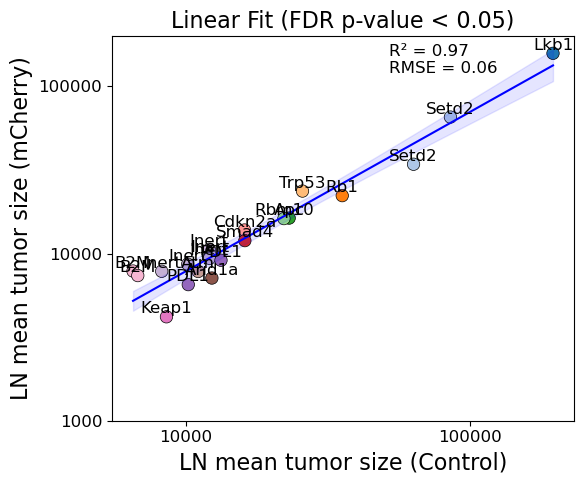

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# ────────────────────────────────────────────────────────────────────────────────
# Publication settings and user‐configurable options
# ────────────────────────────────────────────────────────────────────────────────
# Font sizes
font_label_size = 16        # axis labels
font_tick_size = 12         # x/y tick labels
font_text_size = 12         # annotation text (gene names, p‐values)
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['axes.labelsize']  = font_label_size
plt.rcParams['xtick.labelsize'] = font_tick_size
plt.rcParams['ytick.labelsize'] = font_tick_size
plt.rcParams['font.size']       = font_text_size

# Figure size (in inches)
fig_width, fig_height = 6, 5

# ────────────────────────────────────────────────────────────────────────────────

# ────────────────────────────────────────────────────────────────────────────────
# 1. Define focal columns (before log10 transformation)
# ────────────────────────────────────────────────────────────────────────────────
focal_x = 'LN_mean_NI'
focal_y = 'LN_mean_MI'

# ────────────────────────────────────────────────────────────────────────────────
# 2. Log10-transform focal columns
# ────────────────────────────────────────────────────────────────────────────────
ix = f"Log10_{focal_x}"
iy = f"Log10_{focal_y}"
df_merge[ix] = np.log10(df_merge[focal_x])
df_merge[iy] = np.log10(df_merge[focal_y])

# ────────────────────────────────────────────────────────────────────────────────
# 3. Exclude specified genes for fitting
# ────────────────────────────────────────────────────────────────────────────────
excluded_genes = ['B2M', 'PDL1','Keap1']
temp_df = df_merge.copy()
temp_sub_df = temp_df.loc[~temp_df['Targeted_gene_name'].isin(excluded_genes)].copy()

# ────────────────────────────────────────────────────────────────────────────────
# 4. Scatterplot setup
# ────────────────────────────────────────────────────────────────────────────────
temp_x_label = 'LN mean tumor size (Control)'
temp_y_label = 'LN mean tumor size (mCherry)'
dot_size = 80

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
sns.scatterplot(
    data=temp_df,
    x=ix,
    y=iy,
    hue='Targeted_gene_name',
    palette=gene_color_map,
    edgecolor='black',
    linewidth=0.5,
    s=dot_size,
    ax=ax,
    legend=False
)

# ────────────────────────────────────────────────────────────────────────────────
# 5. Fit a linear (deg=1) model to the subset
# ────────────────────────────────────────────────────────────────────────────────
# np.polyfit with deg=1 returns [slope, intercept]
p_lin = np.polyfit(temp_sub_df[ix], temp_sub_df[iy], deg=1)
y_fit_sub = np.polyval(p_lin, temp_sub_df[ix])

x_min, x_max = temp_df[ix].min(), temp_df[ix].max()
x_range = np.linspace(x_min, x_max, 100)
y_fit_range = np.polyval(p_lin, x_range)

# ────────────────────────────────────────────────────────────────────────────────
# 6. Plot linear fit and its 95% CI band
# ────────────────────────────────────────────────────────────────────────────────
ax.plot(
    x_range,
    y_fit_range,
    color='blue',
    linewidth=1.5
)

# Compute σ_model from subset residuals (ddof=2 for unbiased estimate of 2 parameters: slope & intercept)
residuals_sub = temp_sub_df[iy] - y_fit_sub
var_res = np.var(residuals_sub, ddof=2)


# Build design matrices for CI of linear fit
X_obs = temp_sub_df[ix].to_numpy()
X_design = np.vstack([X_obs, np.ones_like(X_obs)]).T        # shape = (n_sub, 2)
X_rng = np.vstack([x_range, np.ones_like(x_range)]).T       # shape = (100, 2)
cov_mat = np.linalg.inv(X_design.T @ X_design) * var_res    # (2×2)
SE_fit = np.sqrt(np.sum((X_rng @ cov_mat) * X_rng, axis=1))  # length = 100

y_upper = y_fit_range + 1.96 * SE_fit
y_lower = y_fit_range - 1.96 * SE_fit

ax.fill_between(
    x_range,
    y_lower,
    y_upper,
    color='blue',
    alpha=0.1
)

# ────────────────────────────────────────────────────────────────────────────────
# 7. Compute R² and RMSE on the subset, then annotate
# ────────────────────────────────────────────────────────────────────────────────
r2_lin  = r2_score(temp_sub_df[iy], y_fit_sub)
rmse_lin = np.sqrt(mean_squared_error(temp_sub_df[iy], y_fit_sub))

ax.text(
    0.60,
    0.98,
    f'R² = {r2_lin:.2f}\nRMSE = {rmse_lin:.2f}',
    transform=ax.transAxes,
    fontsize=font_text_size,
    verticalalignment='top',
    color='black'
)

# ────────────────────────────────────────────────────────────────────────────────
# 9. Annotate Gene names 
# ────────────────────────────────────────────────────────────────────────────────

for _, row in temp_df.iterrows():
    x, y = row[ix], row[iy]
    gene = row['Targeted_gene_name']
    ax.text(x, y + 0.02, gene, fontsize=font_text_size, color='black', ha='center')


# ────────────────────────────────────────────────────────────────────────────────
# 10. Adjust axis ticks to show original-scale values on log10 axes
# ────────────────────────────────────────────────────────────────────────────────
orig_xticks = [10000, 100000]
ax.set_xticks(np.log10(orig_xticks))
ax.set_xticklabels(orig_xticks)

orig_yticks = [1000, 10000, 100000]
ax.set_yticks(np.log10(orig_yticks))
ax.set_yticklabels(orig_yticks)
# ────────────────────────────────────────────────────────────────────────────────
# 11. Finalize labels, title, and optionally save the figure
# ────────────────────────────────────────────────────────────────────────────────
ax.set_xlabel(temp_x_label)
ax.set_ylabel(temp_y_label)
ax.set_title('Linear Fit (FDR p-value < 0.05)', fontsize=font_label_size)

plt.tight_layout()

plt.show()


---

## 4 Relative resistence (SIIN) vs primary growth rate (Fig. 6D)

In [43]:
df1 = bt_summary_df[
    (bt_summary_df["Vector_type"] == "Lenti-Control")
].copy()

df2 = relative_resistance_effect_df[
    (relative_resistance_effect_df["Vector_type"] == "Lenti-SIINFEKL")
].copy()

# Merge filtered dataframes on shared identifiers
df_merge = df1.merge(
    df2,
    on=["gRNA", "Targeted_gene_name", "Numbered_gene_name"]
)

/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_4938/1697735168.py:209: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_ticks_list)
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_4938/1697735168.py:212: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_ticks_list)


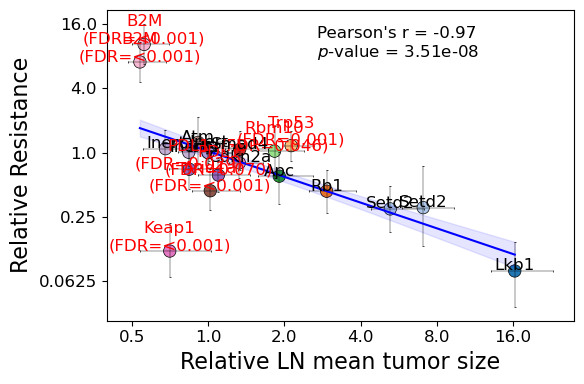

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import RANSACRegressor, LinearRegression
from scipy.stats import norm, pearsonr
from statsmodels.stats.multitest import multipletests

# ────────────────────────────────────────────────────────────────────────────────
# User‐configurable parameters
# ────────────────────────────────────────────────────────────────────────────────
# Columns (before log2-transform)
FOCAL_X = 'LN_mean_relative'
FOCAL_Y = 'LN_mean_relative_fold'

# Axis‐label strings (independent “variables”)
X_AXIS_LABEL = 'Relative LN mean tumor size'
Y_AXIS_LABEL = 'Relative Resistance'

# Initial exclusion list
EXCLUDED_GENES = ['B2M', 'PDL1']

# RANSAC threshold
SIGMA_THRESHOLD = np.log2(1.5)

# FDR alpha
FDR_ALPHA = 0.1

# Figure size + save path
FIG_WIDTH, FIG_HEIGHT = 6, 4
SAVE_PATH = "Revision_fig/SINN_adaptive_Resistance_LNMean_plot.pdf"
# SAVE_PATH = False

# Publication font sizes
FONT_LABEL_SIZE = 16
FONT_TICK_SIZE  = 12
FONT_TEXT_SIZE  = 12

# ────────────────────────────────────────────────────────────────────────────────
# 0. Configure matplotlib rcParams
# ────────────────────────────────────────────────────────────────────────────────
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['axes.labelsize']  = FONT_LABEL_SIZE
plt.rcParams['xtick.labelsize'] = FONT_TICK_SIZE
plt.rcParams['ytick.labelsize'] = FONT_TICK_SIZE
plt.rcParams['font.size']       = FONT_TEXT_SIZE


# ────────────────────────────────────────────────────────────────────────────────
# 1. Prepare data: log2‐transform focal columns
# ────────────────────────────────────────────────────────────────────────────────
ix = f"Log2_{FOCAL_X}"
iy = f"Log2_{FOCAL_Y}"

df_merge[ix] = np.log2(df_merge[FOCAL_X])
df_merge[iy] = np.log2(df_merge[FOCAL_Y])

temp_df = df_merge.copy()


# ────────────────────────────────────────────────────────────────────────────────
# 2. Initial exclusion and RANSAC outlier detection
# ────────────────────────────────────────────────────────────────────────────────
temp_ransac_df = temp_df.loc[
    ~temp_df['Targeted_gene_name'].isin(EXCLUDED_GENES)
].copy()

X_ransac = temp_ransac_df[[ix]].values
y_ransac = temp_ransac_df[iy].values

ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=0.6,
    residual_threshold=SIGMA_THRESHOLD
)
ransac.fit(X_ransac, y_ransac)

inlier_mask  = ransac.inlier_mask_
outlier_mask = ~inlier_mask

outlier_genes = temp_ransac_df.loc[outlier_mask, 'Targeted_gene_name'].tolist()
excluded_genes_extended = EXCLUDED_GENES + outlier_genes

# ────────────────────────────────────────────────────────────────────────────────
# 3. Build final subset for OLS using remaining genes
# ────────────────────────────────────────────────────────────────────────────────
temp_final_df = temp_df.loc[
    ~temp_df['Targeted_gene_name'].isin(excluded_genes_extended)
].copy()

p_lin = np.polyfit(temp_final_df[ix], temp_final_df[iy], deg=1)
y_fit_sub = np.polyval(p_lin, temp_final_df[ix])

x_min, x_max = temp_df[ix].min(), temp_df[ix].max()
x_range = np.linspace(x_min, x_max, 100)
y_fit_range = np.polyval(p_lin, x_range)

residuals_sub = temp_final_df[iy] - y_fit_sub
var_res = np.var(residuals_sub, ddof=2)
sigma_model = np.sqrt(var_res)

X_obs = temp_final_df[ix].to_numpy()
X_design = np.vstack([X_obs, np.ones_like(X_obs)]).T
X_rng = np.vstack([x_range, np.ones_like(x_range)]).T
cov_mat = np.linalg.inv(X_design.T @ X_design) * var_res
SE_fit = np.sqrt(np.sum((X_rng @ cov_mat) * X_rng, axis=1))

y_upper = y_fit_range + 1.96 * SE_fit
y_lower = y_fit_range - 1.96 * SE_fit


# ────────────────────────────────────────────────────────────────────────────────
# 4. Create scatter + regression plot
# ────────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

# (a) All genes in background
sns.scatterplot(
    data=temp_df,
    x=ix,
    y=iy,
    hue='Targeted_gene_name',
    palette=gene_color_map,
    edgecolor='black',
    linewidth=0.5,
    s=80,
    ax=ax,
    legend=False
)
# Adding error bars on original (log) scale
ax.errorbar(temp_df[ix], temp_df[iy], 
             yerr=[temp_df[iy] - np.log2(temp_df[FOCAL_Y + '_2.5P']), np.log2(temp_df[FOCAL_Y + '_97.5P']) - temp_df[iy]], 
             xerr=[temp_df[ix] - np.log2(temp_df[FOCAL_X + '_2.5P']), np.log2(temp_df[FOCAL_X + '_97.5P']) - temp_df[ix]],
             linestyle='', color='black', elinewidth=0.3, capsize=0.5, capthick=0.5)

# (c) Plot the final OLS line (solid blue) + 95% CI (shaded)
ax.plot(
    x_range,
    y_fit_range,
    color='blue',
    linewidth=1.5,
    label='OLS Fit (Final)'
)
ax.fill_between(
    x_range,
    y_lower,
    y_upper,
    color='blue',
    alpha=0.1,
    label='95% CI'
)

# ────────────────────────────────────────────────────────────────────────────────
# 5. Pearson correlation on the final subset
# ────────────────────────────────────────────────────────────────────────────────
corr_final, pval_final = pearsonr(temp_final_df[ix], temp_final_df[iy])
ax.text(
    0.45,
    0.95,
    f"Pearson's r = {corr_final:.2f}\n$p$-value = {pval_final:.2e}",
    transform=ax.transAxes,
    fontsize=FONT_TEXT_SIZE,
    verticalalignment='top'
)


# ────────────────────────────────────────────────────────────────────────────────
# 6. Compute z‐scores & p‐values for every gene (using σ_model from OLS)
# ────────────────────────────────────────────────────────────────────────────────
temp_df['y_pred_log'] = np.polyval(p_lin, temp_df[ix].values)
temp_df['residual']   = temp_df[iy] - temp_df['y_pred_log']
temp_df['z']          = temp_df['residual'] / sigma_model
temp_df['p']          = 2 * norm.sf(np.abs(temp_df['z']))

reject, pvals_fdr, _, _ = multipletests(
    temp_df['p'], method='fdr_bh', alpha=FDR_ALPHA
)
temp_df['flag_fdr'] = reject
temp_df['p_fdr']     = pvals_fdr


# ────────────────────────────────────────────────────────────────────────────────
# 7. Annotate gene names & p‐values on the scatter
#     • Outliers are orange already
#     • FDR‐significant genes get red text
#     • Others remain black
# ────────────────────────────────────────────────────────────────────────────────
def format_pval(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

for _, row in temp_df.iterrows():
    x_val, y_val = row[ix], row[iy]
    gene         = row['Targeted_gene_name']
    if row['flag_fdr']:
        formatted = format_pval(row['p_fdr'])
        label     = f"{gene}\n(FDR={formatted})"
        ax.text(x_val, y_val + 0.02, label, fontsize=FONT_TEXT_SIZE, color='red', ha='center')
    else:
        ax.text(x_val, y_val + 0.02, gene, fontsize=FONT_TEXT_SIZE, color='black', ha='center')


# ────────────────────────────────────────────────────────────────────────────────
# 8. Finalize labels, title, legend, and save figure
# ────────────────────────────────────────────────────────────────────────────────
ax.set_xlabel(X_AXIS_LABEL)
ax.set_ylabel(Y_AXIS_LABEL)
temp_ticks_list=ax.get_yticks()
new_ticks_list = [2**x for x in temp_ticks_list]
ax.set_yticklabels(new_ticks_list)
temp_ticks_list=ax.get_xticks()
new_ticks_list = [2**x for x in temp_ticks_list]
ax.set_xticklabels(new_ticks_list)
plt.tight_layout()

plt.show()


In [45]:
list_of_trait = ['Numbered_gene_name','z','p','p_fdr','flag_fdr']

In [46]:
excluded_genes_extended

['B2M', 'PDL1', 'Arid1a', 'Keap1', 'Rbm10', 'Trp53']

In [47]:
temp_df[list_of_trait].sort_values(by='z')

,Numbered_gene_name,z,p,p_fdr,flag_fdr
11,Keap1,-12.190742,3.482354e-34,7.312942e-33,True
1,Arid1a,-4.202352,2.641562e-05,1.386820e-04,True
14,PDL1_1,-2.642737,8.223899e-03,2.878365e-02,True
13,PDL1_2,-2.214217,2.681383e-02,7.038631e-02,True
12,Lkb1,-1.763153,7.787468e-02,1.733529e-01,False
8,Neo_2,-1.288924,1.974245e-01,3.454928e-01,False
7,Neo_3,-0.832233,4.052774e-01,6.546789e-01,False
6,NT3,-0.163268,8.703071e-01,9.563468e-01,False
10,Neo_1,-0.150421,8.804327e-01,9.563468e-01,False
5,Cdkn2a,-0.135920,8.918843e-01,9.563468e-01,False


----

## 5 Relative resistence (mCherry) vs primary growth rate (Fig. S14E)

In [48]:
df1 = bt_summary_df[
    (bt_summary_df["Vector_type"] == "Lenti-Control")
].copy()

df2 = relative_resistance_effect_df[
    (relative_resistance_effect_df["Vector_type"] == "Lenti-mCherry")
].copy()

# Merge filtered dataframes on shared identifiers
df_merge = df1.merge(
    df2,
    on=["gRNA", "Targeted_gene_name", "Numbered_gene_name"]
)

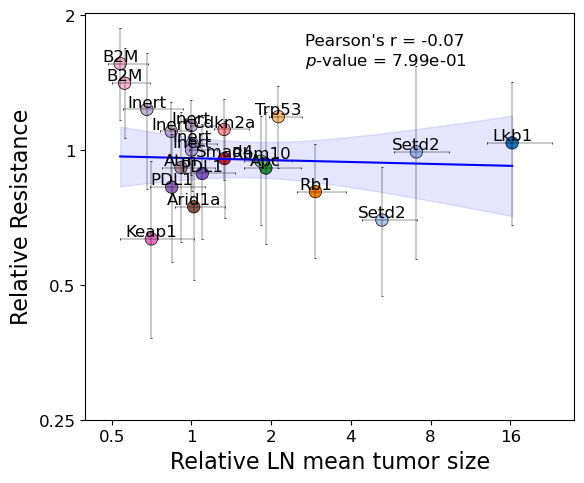

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import RANSACRegressor, LinearRegression
from scipy.stats import norm, pearsonr
from statsmodels.stats.multitest import multipletests

# ────────────────────────────────────────────────────────────────────────────────
# User‐configurable parameters
# ────────────────────────────────────────────────────────────────────────────────
# Columns (before log2-transform)
FOCAL_X = 'LN_mean_relative'
FOCAL_Y = 'LN_mean_relative_fold'

# Axis‐label strings (independent “variables”)
X_AXIS_LABEL = 'Relative LN mean tumor size'
Y_AXIS_LABEL = 'Relative Resistance'

# Initial exclusion list
EXCLUDED_GENES = ['B2M', 'PDL1']

# RANSAC threshold
SIGMA_THRESHOLD = np.log2(1.5)

# FDR alpha
FDR_ALPHA = 0.1

# Figure size + save path
FIG_WIDTH, FIG_HEIGHT = 6, 5
SAVE_PATH = "Revision_fig/mCherry_adaptive_Resistance_LNMean_plot.pdf"

# Publication font sizes
FONT_LABEL_SIZE = 16
FONT_TICK_SIZE  = 12
FONT_TEXT_SIZE  = 12

# ────────────────────────────────────────────────────────────────────────────────
# 0. Configure matplotlib rcParams
# ────────────────────────────────────────────────────────────────────────────────
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['axes.labelsize']  = FONT_LABEL_SIZE
plt.rcParams['xtick.labelsize'] = FONT_TICK_SIZE
plt.rcParams['ytick.labelsize'] = FONT_TICK_SIZE
plt.rcParams['font.size']       = FONT_TEXT_SIZE

# ────────────────────────────────────────────────────────────────────────────────
# 1. Prepare data: log2‐transform focal columns
# ────────────────────────────────────────────────────────────────────────────────
ix = f"Log2_{FOCAL_X}"
iy = f"Log2_{FOCAL_Y}"

df_merge[ix] = np.log2(df_merge[FOCAL_X])
df_merge[iy] = np.log2(df_merge[FOCAL_Y])
temp_df = df_merge.copy()

# ────────────────────────────────────────────────────────────────────────────────
# 2. Initial exclusion and RANSAC outlier detection
# ────────────────────────────────────────────────────────────────────────────────
temp_ransac_df = temp_df.loc[
    ~temp_df['Targeted_gene_name'].isin(EXCLUDED_GENES)
].copy()

X_ransac = temp_ransac_df[[ix]].values
y_ransac = temp_ransac_df[iy].values

ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=0.6,
    residual_threshold=SIGMA_THRESHOLD
)
ransac.fit(X_ransac, y_ransac)

inlier_mask  = ransac.inlier_mask_
outlier_mask = ~inlier_mask

outlier_genes = temp_ransac_df.loc[outlier_mask, 'Targeted_gene_name'].tolist()
excluded_genes_extended = EXCLUDED_GENES + outlier_genes

# ────────────────────────────────────────────────────────────────────────────────
# 3. Build final subset for OLS using remaining genes
# ────────────────────────────────────────────────────────────────────────────────
temp_final_df = temp_df.loc[
    ~temp_df['Targeted_gene_name'].isin(excluded_genes_extended)
].copy()

p_lin = np.polyfit(temp_final_df[ix], temp_final_df[iy], deg=1)
y_fit_sub = np.polyval(p_lin, temp_final_df[ix])

x_min, x_max = temp_df[ix].min(), temp_df[ix].max()
x_range = np.linspace(x_min, x_max, 100)
y_fit_range = np.polyval(p_lin, x_range)

residuals_sub = temp_final_df[iy] - y_fit_sub
var_res = np.var(residuals_sub, ddof=2)
sigma_model = np.sqrt(var_res)

X_obs = temp_final_df[ix].to_numpy()
X_design = np.vstack([X_obs, np.ones_like(X_obs)]).T
X_rng = np.vstack([x_range, np.ones_like(x_range)]).T
cov_mat = np.linalg.inv(X_design.T @ X_design) * var_res
SE_fit = np.sqrt(np.sum((X_rng @ cov_mat) * X_rng, axis=1))

y_upper = y_fit_range + 1.96 * SE_fit
y_lower = y_fit_range - 1.96 * SE_fit


# ────────────────────────────────────────────────────────────────────────────────
# 4. Create scatter + regression plot
# ────────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

# (a) All genes in background
sns.scatterplot(
    data=temp_df,
    x=ix,
    y=iy,
    hue='Targeted_gene_name',
    palette=gene_color_map,
    edgecolor='black',
    linewidth=0.5,
    s=80,
    ax=ax,
    legend=False
)

ax.errorbar(temp_df[ix], temp_df[iy], 
             yerr=[temp_df[iy] - np.log2(temp_df[FOCAL_Y + '_2.5P']), np.log2(temp_df[FOCAL_Y + '_97.5P']) - temp_df[iy]], 
             xerr=[temp_df[ix] - np.log2(temp_df[FOCAL_X + '_2.5P']), np.log2(temp_df[FOCAL_X + '_97.5P']) - temp_df[ix]],
             linestyle='', color='black', elinewidth=0.3, capsize=0.5, capthick=0.5)

# (c) Plot the final OLS line (solid blue) + 95% CI (shaded)
ax.plot(
    x_range,
    y_fit_range,
    color='blue',
    linewidth=1.5,
    label='OLS Fit (Final)'
)
ax.fill_between(
    x_range,
    y_lower,
    y_upper,
    color='blue',
    alpha=0.1,
    label='95% CI'
)

# ────────────────────────────────────────────────────────────────────────────────
# 5. Pearson correlation on the final subset
# ────────────────────────────────────────────────────────────────────────────────
corr_final, pval_final = pearsonr(temp_final_df[ix], temp_final_df[iy])
ax.text(
    0.45,
    0.95,
    f"Pearson's r = {corr_final:.2f}\n$p$-value = {pval_final:.2e}",
    transform=ax.transAxes,
    fontsize=FONT_TEXT_SIZE,
    verticalalignment='top'
)


# ────────────────────────────────────────────────────────────────────────────────
# 6. Compute z‐scores & p‐values for every gene (using σ_model from OLS)
# ────────────────────────────────────────────────────────────────────────────────
temp_df['y_pred_log'] = np.polyval(p_lin, temp_df[ix].values)
temp_df['residual']   = temp_df[iy] - temp_df['y_pred_log']
temp_df['z']          = temp_df['residual'] / sigma_model
temp_df['p']          = 2 * norm.sf(np.abs(temp_df['z']))

reject, pvals_fdr, _, _ = multipletests(
    temp_df['p'], method='fdr_bh', alpha=FDR_ALPHA
)
temp_df['flag_fdr'] = reject
temp_df['p_fdr']     = pvals_fdr


# ────────────────────────────────────────────────────────────────────────────────
# 7. Annotate gene names & p‐values on the scatter
#     • Outliers are orange already
#     • FDR‐significant genes get red text
#     • Others remain black
# ────────────────────────────────────────────────────────────────────────────────
def format_pval(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

for _, row in temp_df.iterrows():
    x_val, y_val = row[ix], row[iy]
    gene         = row['Targeted_gene_name']
    if row['flag_fdr']:
        formatted = format_pval(row['p_fdr'])
        label     = f"{gene}\n(FDR={formatted})"
        ax.text(x_val, y_val + 0.02, label, fontsize=FONT_TEXT_SIZE, color='red', ha='center')
    else:
        ax.text(x_val, y_val + 0.02, gene, fontsize=FONT_TEXT_SIZE, color='black', ha='center')


# ────────────────────────────────────────────────────────────────────────────────
# 8. Finalize labels, title, legend, and save figure
# ────────────────────────────────────────────────────────────────────────────────
ax.set_xlabel(X_AXIS_LABEL)
ax.set_ylabel(Y_AXIS_LABEL)

orig_xticks = [1/2,1,2,4,8,16]
ax.set_xticks(np.log2(orig_xticks))
ax.set_xticklabels(orig_xticks)

orig_yticks = [1/4, 1/2,1, 2]
ax.set_yticks(np.log2(orig_yticks))
ax.set_yticklabels(orig_yticks)
plt.tight_layout()

plt.show()


----

## 6 Tumor number (SIIN) vs primary tumor growth

In [50]:
# Define file paths for input data
normal_path = 'data/Normal_BT_gRNA_level_summary_df.csv'

# Load adaptive (Control) data and filter for required conditions
df1 = bt_summary_df[
    (bt_summary_df["Vector_type"] == "Lenti-Control")
].copy()

# Load normal (SIINFEKL) data and filter for required conditions
normal_df = (
    pd.read_csv(normal_path)
    .query("Mouse_genotype == 'KC' and Vector_type == 'Lenti-SIINFEKL'")
    .copy()
)

# Merge the filtered DataFrames on common columns
df_merge = df1.merge(
    normal_df,
    on=['gRNA', 'Targeted_gene_name', 'Numbered_gene_name'],
    suffixes=('_A', '_N')  # '_A' for Adaptive/Control, '_N' for Normal/SIINFEKL
)

/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_4938/3372224065.py:175: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{2**x:.2g}" for x in x_ticks])


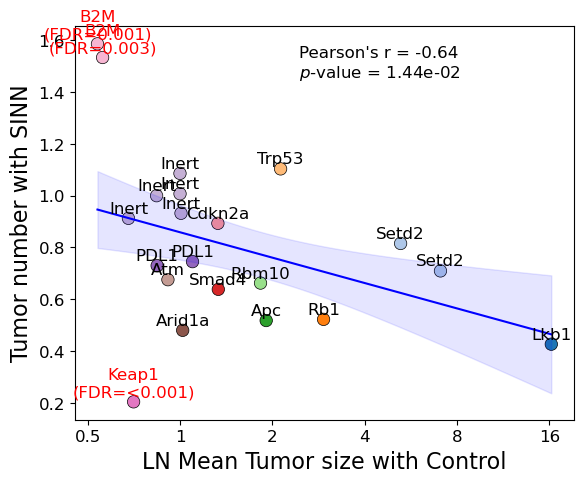

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import RANSACRegressor, LinearRegression
from scipy.stats import norm, pearsonr
from statsmodels.stats.multitest import multipletests

# ────────────────────────────────────────────────────────────────────────────────
# User‐configurable parameters
# ────────────────────────────────────────────────────────────────────────────────
FOCAL_X = 'LN_mean_relative_A'        # will be log2-transformed for modeling
FOCAL_Y = 'TTN_normalized_relative'   # stays in ORIGINAL scale (no log)

X_AXIS_LABEL = 'LN Mean Tumor size with Control'
Y_AXIS_LABEL = 'Tumor number with SINN'

EXCLUDED_GENES = ['B2M', 'PDL1']

RANSAC_RESID_THRESHOLD = 0.25

# FDR alpha
FDR_ALPHA = 0.1

# Figure size + save path
FIG_WIDTH, FIG_HEIGHT = 6, 5
SAVE_PATH = "Revision_fig/Control_TTN_vs_SINN_LNMean_plot.pdf.pdf"

# Publication font sizes
FONT_LABEL_SIZE = 16
FONT_TICK_SIZE  = 12
FONT_TEXT_SIZE  = 12


# ────────────────────────────────────────────────────────────────────────────────
# 0. Configure matplotlib rcParams
# ────────────────────────────────────────────────────────────────────────────────
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['axes.labelsize']  = FONT_LABEL_SIZE
plt.rcParams['xtick.labelsize'] = FONT_TICK_SIZE
plt.rcParams['ytick.labelsize'] = FONT_TICK_SIZE
plt.rcParams['font.size']       = FONT_TEXT_SIZE

# ────────────────────────────────────────────────────────────────────────────────
# 1. Prepare data: ONLY log2‐transform X; Y stays raw
# ────────────────────────────────────────────────────────────────────────────────
ix = f"Log2_{FOCAL_X}"   # X in log2
iy = FOCAL_Y             # Y in original scale

df_merge[ix] = np.log2(df_merge[FOCAL_X])

temp_df = df_merge.copy()

# ────────────────────────────────────────────────────────────────────────────────
# 2. Initial exclusion and RANSAC outlier detection (residuals in Y units)
# ────────────────────────────────────────────────────────────────────────────────
temp_ransac_df = temp_df.loc[
    ~temp_df['Targeted_gene_name'].isin(EXCLUDED_GENES)
].copy()

X_ransac = temp_ransac_df[[ix]].values
y_ransac = temp_ransac_df[iy].values

ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=0.6,
    residual_threshold=RANSAC_RESID_THRESHOLD  # NOTE: in Y units
)
ransac.fit(X_ransac, y_ransac)

inlier_mask  = ransac.inlier_mask_
outlier_mask = ~inlier_mask

outlier_genes = temp_ransac_df.loc[outlier_mask, 'Targeted_gene_name'].tolist()
excluded_genes_extended = EXCLUDED_GENES + outlier_genes

# ────────────────────────────────────────────────────────────────────────────────
# 3. Build final subset for OLS using remaining genes
# ────────────────────────────────────────────────────────────────────────────────
temp_final_df = temp_df.loc[
    ~temp_df['Targeted_gene_name'].isin(excluded_genes_extended)
].copy()

# Fit: Y (raw) ~ a * log2(X) + b
p_lin = np.polyfit(temp_final_df[ix], temp_final_df[iy], deg=1)
y_fit_sub = np.polyval(p_lin, temp_final_df[ix])

x_min, x_max = temp_df[ix].min(), temp_df[ix].max()
x_range = np.linspace(x_min, x_max, 100)
y_fit_range = np.polyval(p_lin, x_range)

# Residual variance in Y units
residuals_sub = temp_final_df[iy] - y_fit_sub
var_res = np.var(residuals_sub, ddof=2)
sigma_model = np.sqrt(var_res)

# CI of the fitted mean (x-dependent)
X_obs = temp_final_df[ix].to_numpy()
X_design = np.vstack([X_obs, np.ones_like(X_obs)]).T
X_rng = np.vstack([x_range, np.ones_like(x_range)]).T
cov_mat = np.linalg.inv(X_design.T @ X_design) * var_res
SE_fit = np.sqrt(np.sum((X_rng @ cov_mat) * X_rng, axis=1))

y_upper = y_fit_range + 1.96 * SE_fit
y_lower = y_fit_range - 1.96 * SE_fit

# ────────────────────────────────────────────────────────────────────────────────
# 4. Create scatter + regression plot
# ────────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

sns.scatterplot(
    data=temp_df,
    x=ix,
    y=iy,
    hue='Targeted_gene_name',
    palette=gene_color_map,
    edgecolor='black',
    linewidth=0.5,
    s=80,
    ax=ax,
    legend=False
)

# Final OLS line + 95% CI
ax.plot(x_range, y_fit_range, color='blue', linewidth=1.5, label='OLS Fit (Final)')
ax.fill_between(x_range, y_lower, y_upper, color='blue', alpha=0.1, label='95% CI')

# ────────────────────────────────────────────────────────────────────────────────
# 5. Pearson correlation on the final subset (log2 X vs raw Y)
# ────────────────────────────────────────────────────────────────────────────────
corr_final, pval_final = pearsonr(temp_final_df[ix], temp_final_df[iy])
ax.text(
    0.45, 0.95,
    f"Pearson's r = {corr_final:.2f}\n$p$-value = {pval_final:.2e}",
    transform=ax.transAxes,
    fontsize=FONT_TEXT_SIZE,
    verticalalignment='top'
)

# ────────────────────────────────────────────────────────────────────────────────
# 6. Per-gene z-tests using σ from residuals (in Y units)
# ────────────────────────────────────────────────────────────────────────────────
temp_df['y_pred']  = np.polyval(p_lin, temp_df[ix].values)   # prediction in Y units
temp_df['residual'] = temp_df[iy] - temp_df['y_pred']        # residual in Y units
temp_df['z']        = temp_df['residual'] / sigma_model
temp_df['p']        = 2 * norm.sf(np.abs(temp_df['z']))

reject, pvals_fdr, _, _ = multipletests(temp_df['p'], method='fdr_bh', alpha=FDR_ALPHA)
temp_df['flag_fdr'] = reject
temp_df['p_fdr']    = pvals_fdr

# ────────────────────────────────────────────────────────────────────────────────
# 7. Annotate gene names & p‐values
# ────────────────────────────────────────────────────────────────────────────────
def format_pval(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

for _, row in temp_df.iterrows():
    x_val, y_val = row[ix], row[iy]
    gene         = row['Targeted_gene_name']
    if row['flag_fdr']:
        formatted = format_pval(row['p_fdr'])
        label     = f"{gene}\n(FDR={formatted})"
        ax.text(x_val, y_val + 0.02, label, fontsize=FONT_TEXT_SIZE, color='red', ha='center')
    else:
        ax.text(x_val, y_val + 0.02, gene, fontsize=FONT_TEXT_SIZE, color='black', ha='center')

# ────────────────────────────────────────────────────────────────────────────────
# 8. Labels, ticks, title, save
# ────────────────────────────────────────────────────────────────────────────────
ax.set_xlabel(X_AXIS_LABEL)
ax.set_ylabel(Y_AXIS_LABEL)
x_ticks = ax.get_xticks()
ax.set_xticklabels([f"{2**x:.2g}" for x in x_ticks])
plt.tight_layout()
plt.show()


## 7 Tumor number (mCherry) vs primary tumor growth

In [52]:
# Define file paths for input data
normal_path = 'data/Normal_BT_gRNA_level_summary_df.csv'

# Load adaptive (Control) data and filter for required conditions
df1 = bt_summary_df[
    (bt_summary_df["Vector_type"] == "Lenti-Control")
].copy()

# Load normal (mCherry) data and filter for required conditions
normal_df = (
    pd.read_csv(normal_path)
    .query("Mouse_genotype == 'KC' and Vector_type == 'Lenti-mCherry'")
    .copy()
)

# Merge the filtered DataFrames on common columns
df_merge = df1.merge(
    normal_df,
    on=['gRNA', 'Targeted_gene_name', 'Numbered_gene_name'],
    suffixes=('_A', '_N')  # '_A' for Adaptive/Control, '_N' for Normal/mCherry
)

### 9.2 LN mean vs TTN

/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_4938/1197803742.py:174: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{2**x:.2g}" for x in x_ticks])


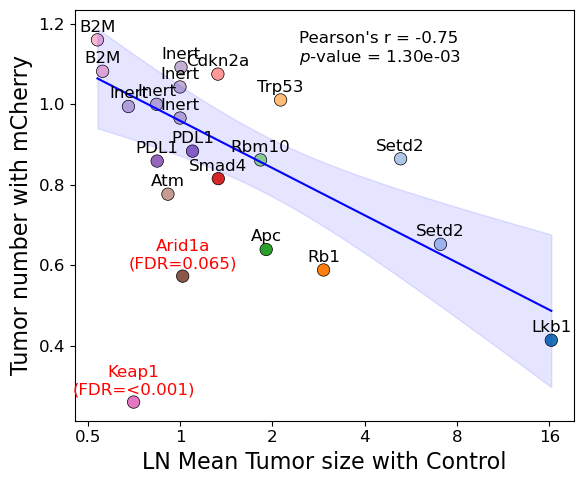

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import RANSACRegressor, LinearRegression
from scipy.stats import norm, pearsonr
from statsmodels.stats.multitest import multipletests

# ────────────────────────────────────────────────────────────────────────────────
# User‐configurable parameters
# ────────────────────────────────────────────────────────────────────────────────
FOCAL_X = 'LN_mean_relative_A'        # will be log2-transformed for modeling
FOCAL_Y = 'TTN_normalized_relative'   # stays in ORIGINAL scale (no log)

X_AXIS_LABEL = 'LN Mean Tumor size with Control'
Y_AXIS_LABEL = 'Tumor number with mCherry'

EXCLUDED_GENES = ['B2M', 'PDL1']

RANSAC_RESID_THRESHOLD = 0.25

# FDR alpha
FDR_ALPHA = 0.1

# Figure size + save path
FIG_WIDTH, FIG_HEIGHT = 6, 5
SAVE_PATH = "Revision_fig/Control_TTN_vs_mCherry_LNMean_plot.pdf.pdf"

# Publication font sizes
FONT_LABEL_SIZE = 16
FONT_TICK_SIZE  = 12
FONT_TEXT_SIZE  = 12

# ────────────────────────────────────────────────────────────────────────────────
# 0. Configure matplotlib rcParams
# ────────────────────────────────────────────────────────────────────────────────
plt.rcParams['pdf.fonttype']    = 42
plt.rcParams['axes.labelsize']  = FONT_LABEL_SIZE
plt.rcParams['xtick.labelsize'] = FONT_TICK_SIZE
plt.rcParams['ytick.labelsize'] = FONT_TICK_SIZE
plt.rcParams['font.size']       = FONT_TEXT_SIZE

# ────────────────────────────────────────────────────────────────────────────────
# 1. Prepare data: ONLY log2‐transform X; Y stays raw
# ────────────────────────────────────────────────────────────────────────────────
ix = f"Log2_{FOCAL_X}"   # X in log2
iy = FOCAL_Y             # Y in original scale

df_merge[ix] = np.log2(df_merge[FOCAL_X])

temp_df = df_merge.copy()

# ────────────────────────────────────────────────────────────────────────────────
# 2. Initial exclusion and RANSAC outlier detection (residuals in Y units)
# ────────────────────────────────────────────────────────────────────────────────
temp_ransac_df = temp_df.loc[
    ~temp_df['Targeted_gene_name'].isin(EXCLUDED_GENES)
].copy()

X_ransac = temp_ransac_df[[ix]].values
y_ransac = temp_ransac_df[iy].values

ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=0.6,
    residual_threshold=RANSAC_RESID_THRESHOLD  # NOTE: in Y units
)
ransac.fit(X_ransac, y_ransac)

inlier_mask  = ransac.inlier_mask_
outlier_mask = ~inlier_mask

outlier_genes = temp_ransac_df.loc[outlier_mask, 'Targeted_gene_name'].tolist()
excluded_genes_extended = EXCLUDED_GENES + outlier_genes

# ────────────────────────────────────────────────────────────────────────────────
# 3. Build final subset for OLS using remaining genes
# ────────────────────────────────────────────────────────────────────────────────
temp_final_df = temp_df.loc[
    ~temp_df['Targeted_gene_name'].isin(excluded_genes_extended)
].copy()

# Fit: Y (raw) ~ a * log2(X) + b
p_lin = np.polyfit(temp_final_df[ix], temp_final_df[iy], deg=1)
y_fit_sub = np.polyval(p_lin, temp_final_df[ix])

x_min, x_max = temp_df[ix].min(), temp_df[ix].max()
x_range = np.linspace(x_min, x_max, 100)
y_fit_range = np.polyval(p_lin, x_range)

# Residual variance in Y units
residuals_sub = temp_final_df[iy] - y_fit_sub
var_res = np.var(residuals_sub, ddof=2)
sigma_model = np.sqrt(var_res)

# CI of the fitted mean (x-dependent)
X_obs = temp_final_df[ix].to_numpy()
X_design = np.vstack([X_obs, np.ones_like(X_obs)]).T
X_rng = np.vstack([x_range, np.ones_like(x_range)]).T
cov_mat = np.linalg.inv(X_design.T @ X_design) * var_res
SE_fit = np.sqrt(np.sum((X_rng @ cov_mat) * X_rng, axis=1))

y_upper = y_fit_range + 1.96 * SE_fit
y_lower = y_fit_range - 1.96 * SE_fit

# ────────────────────────────────────────────────────────────────────────────────
# 4. Create scatter + regression plot
# ────────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

sns.scatterplot(
    data=temp_df,
    x=ix,
    y=iy,
    hue='Targeted_gene_name',
    palette=gene_color_map,
    edgecolor='black',
    linewidth=0.5,
    s=80,
    ax=ax,
    legend=False
)

# Final OLS line + 95% CI
ax.plot(x_range, y_fit_range, color='blue', linewidth=1.5, label='OLS Fit (Final)')
ax.fill_between(x_range, y_lower, y_upper, color='blue', alpha=0.1, label='95% CI')

# ────────────────────────────────────────────────────────────────────────────────
# 5. Pearson correlation on the final subset (log2 X vs raw Y)
# ────────────────────────────────────────────────────────────────────────────────
corr_final, pval_final = pearsonr(temp_final_df[ix], temp_final_df[iy])
ax.text(
    0.45, 0.95,
    f"Pearson's r = {corr_final:.2f}\n$p$-value = {pval_final:.2e}",
    transform=ax.transAxes,
    fontsize=FONT_TEXT_SIZE,
    verticalalignment='top'
)

# ────────────────────────────────────────────────────────────────────────────────
# 6. Per-gene z-tests using σ from residuals (in Y units)
# ────────────────────────────────────────────────────────────────────────────────
temp_df['y_pred']  = np.polyval(p_lin, temp_df[ix].values)   # prediction in Y units
temp_df['residual'] = temp_df[iy] - temp_df['y_pred']        # residual in Y units
temp_df['z']        = temp_df['residual'] / sigma_model
temp_df['p']        = 2 * norm.sf(np.abs(temp_df['z']))

reject, pvals_fdr, _, _ = multipletests(temp_df['p'], method='fdr_bh', alpha=FDR_ALPHA)
temp_df['flag_fdr'] = reject
temp_df['p_fdr']    = pvals_fdr

# ────────────────────────────────────────────────────────────────────────────────
# 7. Annotate gene names & p‐values
# ────────────────────────────────────────────────────────────────────────────────
def format_pval(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"

for _, row in temp_df.iterrows():
    x_val, y_val = row[ix], row[iy]
    gene         = row['Targeted_gene_name']
    if row['flag_fdr']:
        formatted = format_pval(row['p_fdr'])
        label     = f"{gene}\n(FDR={formatted})"
        ax.text(x_val, y_val + 0.02, label, fontsize=FONT_TEXT_SIZE, color='red', ha='center')
    else:
        ax.text(x_val, y_val + 0.02, gene, fontsize=FONT_TEXT_SIZE, color='black', ha='center')

# ────────────────────────────────────────────────────────────────────────────────
# 8. Labels, ticks, title, save
# ────────────────────────────────────────────────────────────────────────────────
ax.set_xlabel(X_AXIS_LABEL)
ax.set_ylabel(Y_AXIS_LABEL)
x_ticks = ax.get_xticks()
ax.set_xticklabels([f"{2**x:.2g}" for x in x_ticks])
plt.tight_layout()
plt.show()
